### Basic ChatBot with LangGraph(graphAPI)

In [2]:
from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph import StateGraph , START, END
from langgraph.graph.message import add_messages



In [3]:
class State(TypedDict):
    # Messages have the type "list". the 'add_messages' function 
    # in the annotation defines how this state key should be updated 
    # (in this case , it appends messsages to the list , rather than overwriting them)
    messages:Annotated[list,add_messages]

graph_builder = StateGraph(State)


In [4]:
graph_builder

In [5]:
import os 
from dotenv import load_dotenv
load_dotenv()


True

In [6]:
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model

llm = init_chat_model("groq:qwen/qwen3-32b")
llm

ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 16384, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x0000021D2DEA56A0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000021D2DEA63C0>, model_name='qwen/qwen3-32b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [7]:
# Node functionality 
def chatbot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}

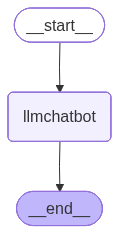

'<think>\nOkay, the user said "Hi". That\'s pretty open-ended. I should respond in a friendly and welcoming way. Maybe ask how I can assist them today. Let me keep it simple and positive.\n</think>\n\nHello! How can I assist you today? 😊'

In [8]:
graph_builder = StateGraph(State)

## Adding Node 
graph_builder.add_node("llmchatbot",chatbot)
## Adding Edges
graph_builder.add_edge(START,"llmchatbot")
graph_builder.add_edge("llmchatbot",END)

## compile the graph 
graph = graph_builder.compile()

## visualize the graph 
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

response = graph.invoke({"messages":"Hi"})
response["messages"][-1].content

In [9]:
for event in graph.stream({"messages":"hi how are you ?"}):
    for value in event.values():
        print(value["messages"][-1].content)
    

<think>
Okay, the user is greeting me and asking how I'm doing. I need to respond in a friendly and conversational way. First, I should acknowledge their greeting. Since I'm an AI and don't actually have feelings, I should be clear about that but still sound warm. I can mention that I'm here to help and ask how I can assist them. Keeping it simple and approachable is key. Let me check if there's anything else to consider. Maybe add an emoji to make it more personable. Yeah, that should work.
</think>

Hi! 😊 I'm just a virtual assistant, so I don't have feelings, but I'm here and ready to help! How can I assist you today?


### ChatBot with Tool 

In [10]:
from langchain_tavily import TavilySearch

tool = TavilySearch(max_results=2)
tool.invoke("What is langgraph")


{'query': 'What is langgraph',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.ibm.com/think/topics/langgraph',
   'title': 'What is LangGraph? - IBM',
   'content': 'LangGraph, created by LangChain, is an open source AI agent framework designed to build, deploy and manage complex generative AI agent workflows. It provides a set of tools and libraries that enable users to create, run and optimize large language models (LLMs) in a scalable and efficient manner. At its core, LangGraph uses the power of graph-based architectures to model and manage the intricate relationships between various components of an AI agent workflow. The following example can offer a clearer understanding of LangGraph: Think about these graph-based architectures as a powerful configurable map, a “Super-Map.” Users can envision the AI workflow as being “The Navigator” of this “Super-Map.” Finally, in this example, the user is “The Cartographer.” In this sense, the n

In [11]:
## Custom function 
def multiply(a:int,b:int) -> int:
    """ Multiply a and b 
    Args:
        a(int): First int
        b(int): second int
        
    Returns:
        int:output int
    """
    return a * b
tools = [tool,multiply]

In [12]:
llm_with_tool = llm.bind_tools(tools)
llm_with_tool

_ChatModelBinding(bound=ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 16384, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x0000021D2DEA56A0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000021D2DEA63C0>, model_name='qwen/qwen3-32b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and trusted results. Useful for when you need to answer questions about current events. It not only retrieves URLs and snippets, but offers advanced search depths, domain management, time range filters, and image search, this tool delivers real

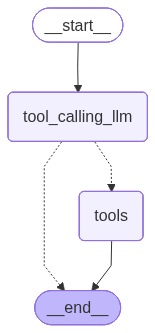

In [13]:
## StateGraph 
from langgraph.graph import StateGraph, START , END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node defination 
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## Graph 

builder = StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result ) from assistance is not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools",END)

## compile the graph 
graph = builder.compile()
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [14]:
response = graph.invoke({"messages":"what is recent ai news"})
response["messages"][-1].content

'{"query": "recent ai news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.cnbc.com/2026/06/11/anthropic-openai-london-expansions-big-tech.html", "title": "Anthropic, OpenAI, other U.S. AI giants launch major London expansions amid talent and revenue scramble - CNBC", "score": 0.6654328, "published_date": "Thu, 11 Jun 2026 10:19:29 GMT", "content": "# Anthropic, OpenAI, other U.S. AI giants launch major London expansions amid talent and revenue scramble. * A number of key AI companies have announced major expansions in London over the the past year, as the sector races to secure key talent and build commercial revenue. * In recent months, both OpenAI and Anthropic said they\'d be upping headcount in the U.K. capital. * Access to top technical and commercial talent is a key driver, analysts told CNBC. A slew of U.S. Big Tech and AI companies are racing to expand in London as they look to take advantage of the city\'s deep talent pools amid a

In [15]:
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

what is recent ai news
================================== Ai Message ==================================
Tool Calls:
  tavily_search (et87kybyp)
 Call ID: et87kybyp
  Args:
    query: recent ai news
    time_range: week
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "recent ai news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.cnbc.com/2026/06/11/anthropic-openai-london-expansions-big-tech.html", "title": "Anthropic, OpenAI, other U.S. AI giants launch major London expansions amid talent and revenue scramble - CNBC", "score": 0.6654328, "published_date": "Thu, 11 Jun 2026 10:19:29 GMT", "content": "# Anthropic, OpenAI, other U.S. AI giants launch major London expansions amid talent and revenue scramble. * A number of key AI companies have announced major expansions in London over

In [16]:
response = graph.invoke({"messages":"what is 2 multiped by 3"})
for m in response["messages"]:
    m.pretty_print()


================================ Human Message =================================

what is 2 multiped by 3
================================== Ai Message ==================================
Tool Calls:
  multiply (2w3kwq4p6)
 Call ID: 2w3kwq4p6
  Args:
    a: 2
    b: 3
================================= Tool Message =================================
Name: multiply

6


In [17]:
response = graph.invoke({"messages":"Give me the recent ai news and multiply 5 by 10"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Give me the recent ai news and multiply 5 by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (yk88xamc6)
 Call ID: yk88xamc6
  Args:
    query: recent AI news
    time_range: week
    topic: general
  multiply (26bnen8ye)
 Call ID: 26bnen8ye
  Args:
    a: 5
    b: 10
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://blog.google/innovation-and-ai/technology/ai/google-ai-updates-may-2026", "title": "The latest AI news we announced in May 2026", "content": "Here's a recap of our biggest AI updates from May, including announcements from Google I/O 2026, the Android Show and Google Health. T. The Keyword Team.", "score": 0.75464433, "raw_content": null}, {"url": "https://ai.economi

### reAct Agent Architecture 

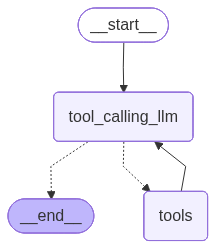

In [18]:
## StateGraph 
from langgraph.graph import StateGraph, START , END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node defination 
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## Graph 

builder = StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result ) from assistance is not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")

## compile the graph 
graph = builder.compile()
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [19]:
response = graph.invoke({"messages":"Give me the recent ai news and multiply 5 by 10"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Give me the recent ai news and multiply 5 by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (g37gz0x5e)
 Call ID: g37gz0x5e
  Args:
    query: recent AI news
    time_range: week
    topic: general
  multiply (09n1km5eq)
 Call ID: 09n1km5eq
  Args:
    a: 5
    b: 10
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.reddit.com/r/IdentityV/comments/1txi8uz/oh_lord_the_ai_in_this_stream", "title": "Oh lord the AI in this stream : r/IdentityV", "content": "The recent AI accusations got too heated that some started seeing AI where it may not be, so I'd rather go through all possible angles instead of immediately", "score": 0.61307496, "raw_content": null}, {"url": "https://www